<a href="https://colab.research.google.com/github/Jull-kyori/CVision/blob/master/TUGAS_PENAMBANGAN_DATA_DT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# 1. Import library
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
# 2. Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# 3. Load dataset dari Google Drive
df = pd.read_csv('/content/drive/MyDrive/dataset/diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# 4. Cek dataset
print("Jumlah data:", df.shape[0])
print("Jumlah kolom:", df.shape[1])
print(df.info())

df['Outcome'].value_counts()

Jumlah data: 768
Jumlah kolom: 9
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
None


,count
Outcome,
0,500
1,268


In [ ]:
# 5. Pisahkan fitur dan label
X = df.drop(columns=['Outcome'])
y = df['Outcome']

print("Fitur:")
print(X.head())

print("\nLabel:")
print(y.head())

Fitur:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Label:
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


In [ ]:
# 6. Split data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data training:", len(X_train))
print("Jumlah data testing:", len(X_test))

Jumlah data training: 614
Jumlah data testing: 154


In [ ]:
# 7. Membuat model Decision Tree
model = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [ ]:
# 8. Prediksi data testing
y_pred = model.predict(X_test)

hasil_prediksi = pd.DataFrame({
    "Data Asli": y_test.values,
    "Hasil Prediksi": y_pred
})

hasil_prediksi["Data Asli"] = hasil_prediksi["Data Asli"].map({
    0: "Tidak Diabetes",
    1: "Diabetes"
})

hasil_prediksi["Hasil Prediksi"] = hasil_prediksi["Hasil Prediksi"].map({
    0: "Tidak Diabetes",
    1: "Diabetes"
})

hasil_prediksi.head(10)

,Data Asli,Hasil Prediksi
0,Tidak Diabetes,Diabetes
1,Tidak Diabetes,Tidak Diabetes
2,Tidak Diabetes,Tidak Diabetes
3,Diabetes,Diabetes
4,Tidak Diabetes,Tidak Diabetes
5,Tidak Diabetes,Tidak Diabetes
6,Diabetes,Tidak Diabetes
7,Diabetes,Diabetes
8,Tidak Diabetes,Tidak Diabetes
9,Tidak Diabetes,Diabetes


In [ ]:
# 9. Evaluasi model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Akurasi  :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Tidak Diabetes", "Diabetes"]
))

Akurasi  : 0.8051948051948052
Precision: 0.74
Recall   : 0.6851851851851852
F1-Score : 0.7115384615384616

Classification Report:
                precision    recall  f1-score   support

Tidak Diabetes       0.84      0.87      0.85       100
      Diabetes       0.74      0.69      0.71        54

      accuracy                           0.81       154
     macro avg       0.79      0.78      0.78       154
  weighted avg       0.80      0.81      0.80       154



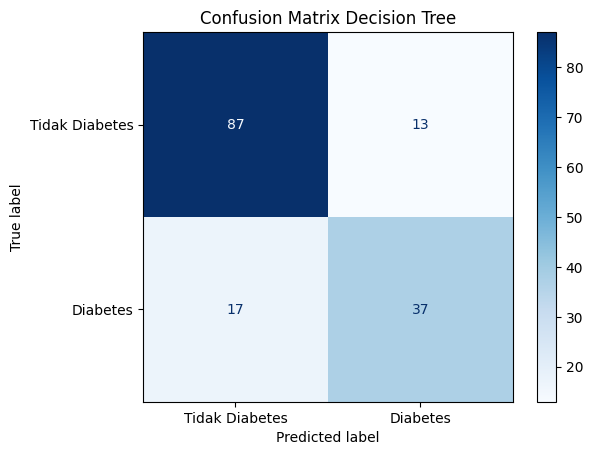

In [ ]:
# 10. Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Tidak Diabetes", "Diabetes"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix Decision Tree")
plt.show()